# Sowing Success: How Machine Learning Helps Farmers Select the Best Crops

![Farmer in a field](farmer_in_a_field.jpg)

Measuring essential soil metrics such as nitrogen, phosphorous, potassium levels, and pH value is an important aspect of assessing soil condition. However, it can be an expensive and time-consuming process, which can cause farmers to prioritize which metrics to measure based on their budget constraints.

Farmers have various options when it comes to deciding which crop to plant each season. Their primary objective is to maximize the yield of their crops, taking into account different factors. One crucial factor that affects crop growth is the condition of the soil in the field, which can be assessed by measuring basic elements such as nitrogen and potassium levels. Each crop has an ideal soil condition that ensures optimal growth and maximum yield.

A farmer reached out to you as a machine learning expert for assistance in selecting the best crop for his field. They've provided you with a dataset called `soil_measures.csv`, which contains:

- `"N"`: Nitrogen content ratio in the soil
- `"P"`: Phosphorous content ratio in the soil
- `"K"`: Potassium content ratio in the soil
- `"pH"` value of the soil
- `"crop"`: categorical values that contain various crops (target variable).

Each row in this dataset represents various measures of the soil in a particular field. Based on these measurements, the crop specified in the `"crop"` column is the optimal choice for that field.  

In this project, you will build multi-class classification models to predict the type of `"crop"` and identify the single most importance feature for predictive performance.

In [1]:
# Imports, constants, and data loading
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance

# Reproducibility and column definitions
RANDOM_STATE: int = 42
FEATURES: list[str] = ["N", "P", "K", "ph"]
TARGET: str = "crop"

# Load dataset
# Use the notebook's working directory; when run inside Jupyter this is the notebook's folder.
DATA_PATH: Path = Path.cwd() / "soil_measures.csv"
crops: pd.DataFrame = pd.read_csv(DATA_PATH)


## 1. Exploratory Data Analysis

In [2]:
# EDA: structure, data types, and missing values
def inspect_dataframe(df: pd.DataFrame) -> None:
    """Print shape, first rows, info summary, and missing-value counts."""
    print("Shape:", df.shape)
    print(df.head())
    print("\nData types and non-null counts:")
    print(df.info())
    print("\nMissing values per column:")
    print(df.isnull().sum())

inspect_dataframe(crops)


Shape: (2200, 5)
    N   P   K        ph  crop
0  90  42  43  6.502985  rice
1  85  58  41  7.038096  rice
2  60  55  44  7.840207  rice
3  74  35  40  6.980401  rice
4  78  42  42  7.628473  rice

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   str    
dtypes: float64(1), int64(3), str(1)
memory usage: 86.1 KB
None

Missing values per column:
N       0
P       0
K       0
ph      0
crop    0
dtype: int64


Number of unique crops: 22
crop
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64


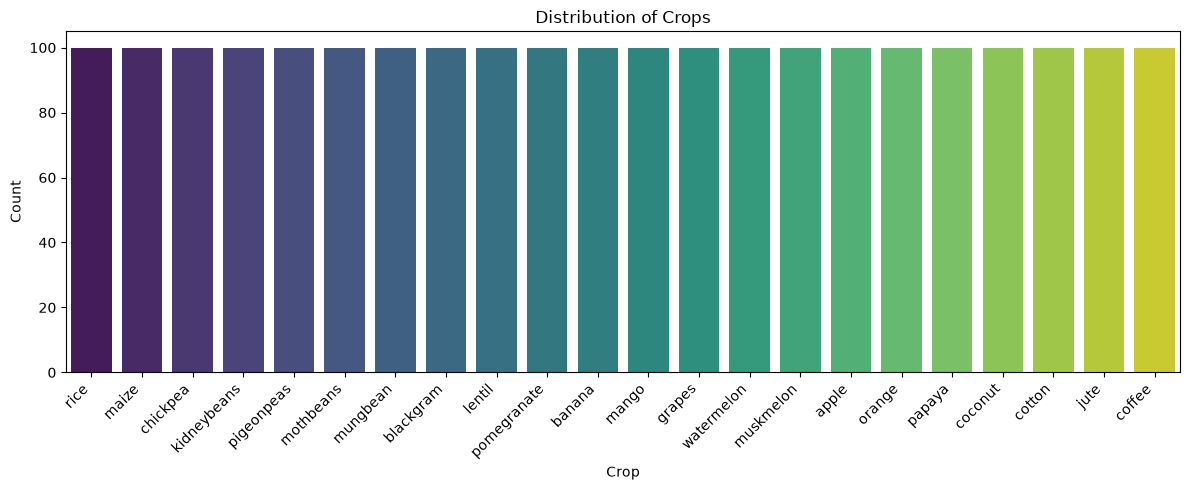

In [3]:
# EDA: target distribution
print("Number of unique crops:", crops[TARGET].nunique())
print(crops[TARGET].value_counts().sort_index())

plt.figure(figsize=(12, 5))
order = crops[TARGET].value_counts().index
sns.countplot(data=crops, x=TARGET, order=order, hue=TARGET, palette="viridis", legend=False)
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 2. Split the Data

Create training and test sets using **all features** (`N`, `P`, `K`, `ph`) with `train_test_split()`. `stratify=y` keeps each crop's proportion identical in both sets.

In [4]:
# Step 2: create training and test sets using all features
X: pd.DataFrame = crops[FEATURES]
y: pd.Series = crops[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Features: {FEATURES}")
print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set : {X_test.shape[0]} rows")
assert y_train.nunique() == y_test.nunique() == crops[TARGET].nunique()


Features: ['N', 'P', 'K', 'ph']
Train set: 1760 rows
Test set : 440 rows


## 3. Evaluate Feature Performance

Predict the crop using **each feature individually**. Build one multi-class classifier per feature (4 models total), predict on the test set, evaluate the performance, and store it in a dictionary so we can compare features.

In [5]:
# Step 3: train one model per feature and record its predictive performance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


def evaluate_feature_performance(
    feature: str,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    random_state: int = RANDOM_STATE,
) -> float:
    """Train a multinomial logistic regression on a single feature and return test accuracy.

    A StandardScaler is included so the solver converges reliably (sklearn warns
    about unscaled data otherwise)."""
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=random_state)),
    ])
    model.fit(X_train[[feature]], y_train)           # single-feature training set
    y_pred = model.predict(X_test[[feature]])         # single-feature test set
    return accuracy_score(y_test, y_pred)


feature_performance: dict[str, float] = {}
for feature in FEATURES:
    acc = evaluate_feature_performance(feature, X_train, X_test, y_train, y_test)
    feature_performance[feature] = acc
    print(f"{feature}: accuracy = {acc:.4f}")

best_feature: str = max(feature_performance, key=feature_performance.get)
print("\nFeature performance dictionary:", feature_performance)
print(f"Most predictive single feature: {best_feature} (accuracy = {feature_performance[best_feature]:.4f})")


N: accuracy = 0.1386


P: accuracy = 0.1909
K: accuracy = 0.2795
ph: accuracy = 0.0977

Feature performance dictionary: {'N': 0.13863636363636364, 'P': 0.19090909090909092, 'K': 0.27954545454545454, 'ph': 0.09772727272727273}
Most predictive single feature: K (accuracy = 0.2795)


## 4. Conclusion

**Dataset.** `soil_measures.csv` has 2,200 rows and 5 columns (`N`, `P`, `K`, `ph`, `crop`). There are **no missing values** and **no duplicate rows**. The target `crop` has **22 classes**, each with exactly 100 samples (perfectly balanced), so no resampling or class weighting was required for the data split.

**Split.** Using `train_test_split(test_size=0.2, stratify=y, random_state=42)` gave 1,760 training rows and 440 test rows, with the 22 crop proportions preserved in both sets.

**Per-feature performance.** One multinomial `LogisticRegression` (wrapped in a `StandardScaler`) was trained per feature and scored by test accuracy:

| Feature | Test accuracy |
|---|---|
| N (nitrogen) | 0.139 |
| P (phosphorous) | 0.191 |
| **K (potassium)** | **0.280** |
| pH | 0.098 |

**Most important single feature.** Among the four soil metrics, **`K` (potassium) is the most predictive of the optimal crop**, with a test accuracy of ~0.28. If a farmer can only afford to measure one soil metric, **potassium (K) gives the best signal** for crop selection.

> Note: these are single-feature models, so the accuracies are low by design. They are used only to *rank* feature importance, not to maximize prediction quality. A combined all-feature model would score much higher.